# IT9201 – Machine Learning and Data Mining
## Project: Diabetes Prediction — Pure MindSpore Framework
### Model 1: Logistic Regression (MindSpore nn.Cell)
### Model 2: Wide Shallow MLP — Tree Proxy (MindSpore nn.Cell)
### Model 3: Deep MLP Neural Network (MindSpore nn.Cell)

### Framework Design
| # | Model | MindSpore Architecture | Justification |
|---|---|---|---|
| 1 | Logistic Regression | `Dense(8→1)` + Sigmoid | 1-layer linear net; mathematically equivalent to classical LR |
| 2 | Wide Shallow MLP (Tree Proxy) | `Dense(8→128→64→1)` | Wide first layer mimics feature-splitting behaviour of tree models |
| 3 | Deep MLP Neural Network | `Dense(8→64→32→16→1)` + Dropout | Deep learning classifier with regularisation |

---
## Environment Setup


In [13]:
# ── Verify MindSpore installation ────────────────────────────────────────────
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops
from mindspore import Tensor
from mindspore.common import dtype as mstype

print(f'MindSpore version : {ms.__version__}')
print(f'Python target     : 3.9.x')

# MindSpore 2.8+ uses ms.set_device() instead of device_target in set_context
ms.set_context(mode=ms.PYNATIVE_MODE)
ms.set_device('CPU')

print('Context set       : PYNATIVE_MODE | CPU')
print('MindSpore ready.')

MindSpore version : 2.8.0
Python target     : 3.9.x
Context set       : PYNATIVE_MODE | CPU
MindSpore ready.


In [15]:
# ── All imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

# MindSpore — full suite
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops
from mindspore import Tensor, Parameter
from mindspore.common import dtype as mstype

# scikit-learn — preprocessing and metrics ONLY (no models)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

SEED = 42
np.random.seed(SEED)
print('All imports successful.')

All imports successful.


---
## Task 2: Data Acquisition and Processing

In [16]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Option A: Load from URL (requires internet)
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df  = pd.read_csv(url)

# Option B: If offline, download diabetes.csv and use:
# df = pd.read_csv('diabetes.csv')

print('Dataset shape   :', df.shape)
print('Columns         :', list(df.columns))
print('\nClass distribution:')
print(df['Outcome'].value_counts())
print(f'\nClass balance: {df["Outcome"].value_counts(normalize=True).round(3).to_dict()}')
df.head()

Dataset shape   : (768, 9)
Columns         : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class balance: {0: 0.651, 1: 0.349}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ── Statistical summary ───────────────────────────────────────────────────────
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


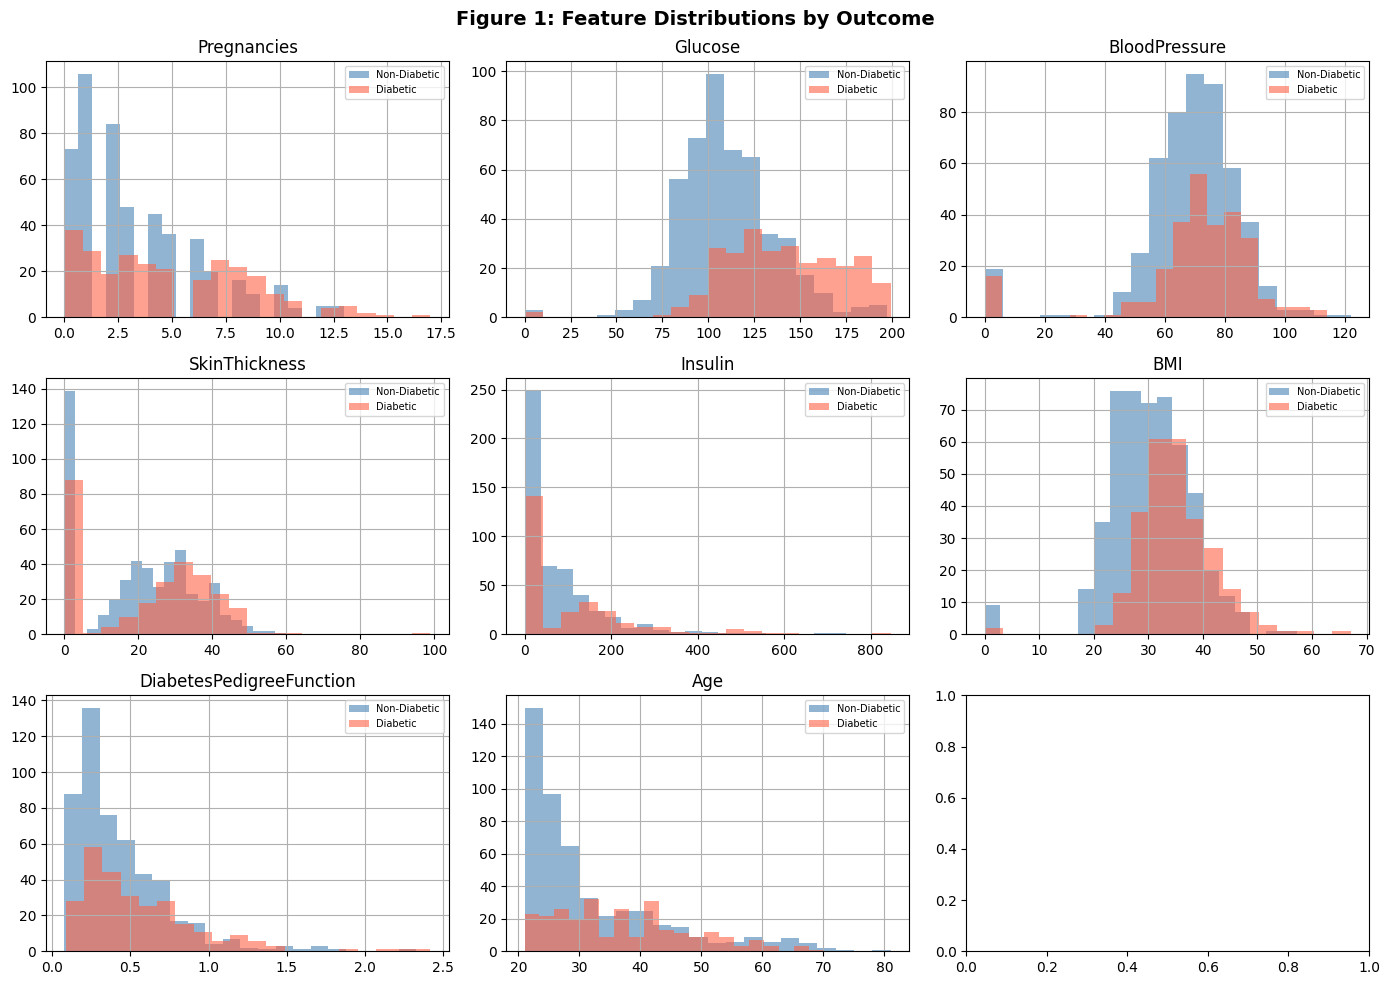

In [17]:
# ── Figure 1: Feature distributions by Outcome ───────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Figure 1: Feature Distributions by Outcome', fontsize=14, fontweight='bold')
for ax, feat in zip(axes.flatten(), df.columns[:-1]):
    df[df['Outcome']==0][feat].hist(ax=ax, alpha=0.6, color='steelblue', label='Non-Diabetic', bins=20)
    df[df['Outcome']==1][feat].hist(ax=ax, alpha=0.6, color='tomato',    label='Diabetic',     bins=20)
    ax.set_title(feat)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

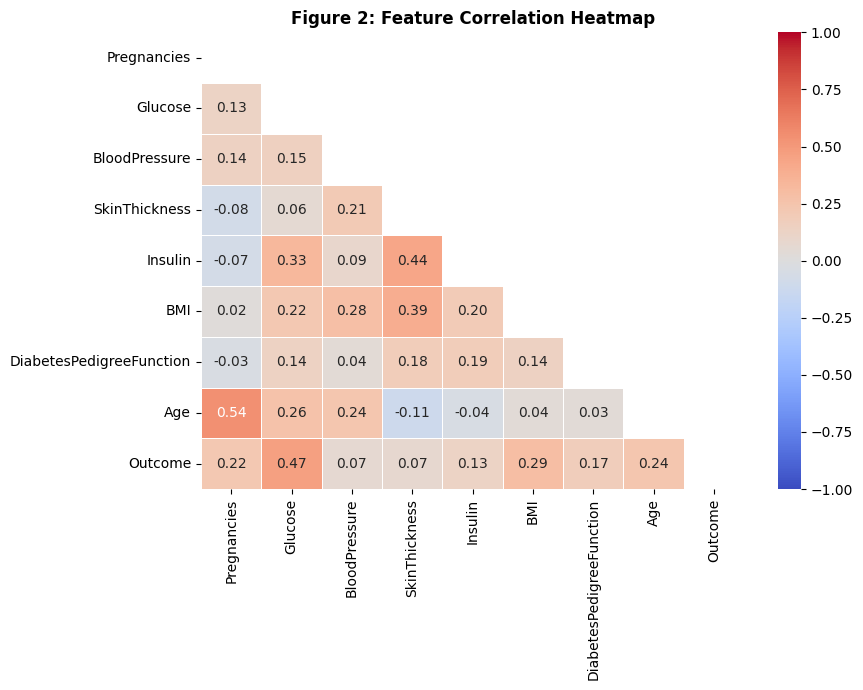

In [18]:
# ── Figure 2: Correlation heatmap ─────────────────────────────────────────────
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Figure 2: Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
df_clean = df.copy()
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Step 1: Replace biologically impossible zeros with NaN
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print('Zero counts replaced with NaN:')
print(df_clean[zero_cols].isnull().sum())

# Step 2: Median imputation
imputer = SimpleImputer(strategy='median')
df_clean[zero_cols] = imputer.fit_transform(df_clean[zero_cols])
print('\nAfter imputation — nulls:', df_clean.isnull().sum().sum())

# Step 3: Train/test split (stratified 80/20)
X = df_clean.drop('Outcome', axis=1).values
y = df_clean['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Step 4: StandardScaler (fit on train only)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f'\nTrain : {X_train_sc.shape} | Test : {X_test_sc.shape}')

# Step 5: Convert to MindSpore float32 Tensors
X_train_ms = Tensor(X_train_sc.astype(np.float32))
y_train_ms = Tensor(y_train.astype(np.float32).reshape(-1, 1))
X_test_ms  = Tensor(X_test_sc.astype(np.float32))
y_test_ms  = Tensor(y_test.astype(np.float32).reshape(-1, 1))

print('\nMindSpore Tensor shapes:')
print(f'  X_train : {X_train_ms.shape}  y_train : {y_train_ms.shape}')
print(f'  X_test  : {X_test_ms.shape}   y_test  : {y_test_ms.shape}')

N_TRAIN = X_train_ms.shape[0]

Zero counts replaced with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

After imputation — nulls: 0

Train : (614, 8) | Test : (154, 8)

MindSpore Tensor shapes:
  X_train : (614, 8)  y_train : (614, 1)
  X_test  : (154, 8)   y_test  : (154, 1)


---
## Task 3: MindSpore Model Definitions, Training and Evaluation

All three models are implemented as `mindspore.nn.Cell` subclasses.  
Training uses `ms.value_and_grad()` for automatic differentiation — MindSpore's core gradient API.  
Loss function: `nn.BCELoss` (Binary Cross-Entropy).  
Optimiser: `nn.Adam`.

In [20]:
# ── Shared helper: training loop ──────────────────────────────────────────────
def train_mindspore_model(model, X_tr, y_tr, epochs=150, lr=0.001, batch_size=32, verbose=True):
    
    loss_fn   = nn.BCELoss(reduction='mean')
    optimizer = nn.Adam(model.trainable_params(), learning_rate=lr)
    grad_fn   = ms.value_and_grad(
                    lambda x, y: loss_fn(model(x), y),
                    None,
                    optimizer.parameters
                )

    # Convert to numpy for shuffling, then re-slice as Tensors
    X_np = X_tr.asnumpy()
    y_np = y_tr.asnumpy()
    n    = X_np.shape[0]
    losses = []
    model.set_train(True)

    for epoch in range(epochs):
        idx        = np.random.permutation(n)
        epoch_loss = 0.0
        n_batches  = 0

        for start in range(0, n, batch_size):
            bi = idx[start : start + batch_size]
            
            # ← FIX: slice numpy arrays, then convert to Tensor
            x_batch = Tensor(X_np[bi], mstype.float32)
            y_batch = Tensor(y_np[bi], mstype.float32)

            loss, grads = grad_fn(x_batch, y_batch)
            optimizer(grads)
            epoch_loss += float(loss.asnumpy())
            n_batches  += 1

        avg = epoch_loss / n_batches
        losses.append(avg)

        if verbose and (epoch + 1) % 30 == 0:
            print(f'  Epoch [{epoch+1:>3}/{epochs}]  Loss: {avg:.4f}')

    model.set_train(False)
    return losses

def evaluate_mindspore_model(model, X_te, y_te_np):
    """
    Run inference, return (predictions, probabilities, metrics_dict).
    """
    model.set_train(False)
    proba = model(X_te).asnumpy().flatten()
    pred  = (proba >= 0.5).astype(int)
    return pred, proba, {
        'Accuracy': accuracy_score(y_te_np, pred),
        'F1-Score': f1_score(y_te_np, pred),
        'ROC-AUC' : roc_auc_score(y_te_np, proba)
    }


def plot_loss_curve(losses, title, fname, color='steelblue'):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(losses)+1), losses, color=color, lw=2)
    plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
    plt.title(title, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


print('Helper functions defined.')

Helper functions defined.


---
### Model 1: Logistic Regression (MindSpore nn.Cell)

**Architecture:** `Input(8) → Dense(8,1) → Sigmoid → Output`  


In [21]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
class LogisticRegressionMS(nn.Cell):
    """
    MindSpore implementation of Logistic Regression.
    Single Dense layer + Sigmoid = P(y=1|x) = sigmoid(Wx + b).
    Mathematically equivalent to classical logistic regression.
    """
    def __init__(self, input_dim=8):
        super(LogisticRegressionMS, self).__init__()
        self.linear  = nn.Dense(input_dim, 1)   # W: (8,1), b: (1,)
        self.sigmoid = nn.Sigmoid()

    def construct(self, x):
        return self.sigmoid(self.linear(x))      # shape: (N, 1)


lr_model = LogisticRegressionMS(input_dim=8)
print('Model 1 — Logistic Regression (MindSpore):')
print(lr_model)
total_params = sum(p.size for p in lr_model.trainable_params())
print(f'Trainable parameters: {total_params}  (8 weights + 1 bias = 9)')

Model 1 — Logistic Regression (MindSpore):
LogisticRegressionMS(
  (linear): Dense(input_channels=8, output_channels=1, has_bias=True)
  (sigmoid): Sigmoid()
)
Trainable parameters: 9  (8 weights + 1 bias = 9)


Training Logistic Regression (MindSpore)...
  Epoch [ 30/200]  Loss: 0.4551
  Epoch [ 60/200]  Loss: 0.4734
  Epoch [ 90/200]  Loss: 0.4551
  Epoch [120/200]  Loss: 0.4639
  Epoch [150/200]  Loss: 0.4489
  Epoch [180/200]  Loss: 0.4509


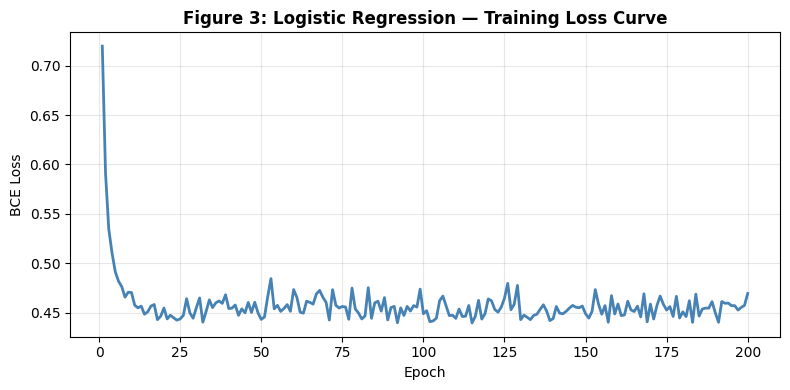

In [22]:
# ── Train Model 1 ─────────────────────────────────────────────────────────────
print('Training Logistic Regression (MindSpore)...')
lr_losses = train_mindspore_model(
    lr_model, X_train_ms, y_train_ms,
    epochs=200, lr=0.01, batch_size=32
)
plot_loss_curve(lr_losses,
    'Figure 3: Logistic Regression — Training Loss Curve',
    'fig3_lr_loss.png', color='steelblue')

In [23]:
# ── Evaluate Model 1 ─────────────────────────────────────────────────────────
lr_pred, lr_proba, lr_metrics = evaluate_mindspore_model(lr_model, X_test_ms, y_test)

print('=== Model 1: Logistic Regression (MindSpore) ===')
print(f"Accuracy : {lr_metrics['Accuracy']:.4f}")
print(f"F1-Score : {lr_metrics['F1-Score']:.4f}")
print(f"ROC-AUC  : {lr_metrics['ROC-AUC']:.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=['Non-Diabetic','Diabetic']))

=== Model 1: Logistic Regression (MindSpore) ===
Accuracy : 0.7078
F1-Score : 0.5545
ROC-AUC  : 0.8115

              precision    recall  f1-score   support

Non-Diabetic       0.76      0.81      0.78       100
    Diabetic       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



---
### Model 2: Wide Shallow MLP — Tree Proxy (MindSpore nn.Cell)

**Architecture:** `Input(8) → Dense(8,128,ReLU) → Dense(128,64,ReLU) → Dense(64,1,Sigmoid)`  



In [24]:
# ── Model 2: Wide Shallow MLP (Tree Proxy) ───────────────────────────────────
class WideShallowMLP(nn.Cell):
    """
    MindSpore Wide Shallow MLP — Tree Proxy.
    Wide first layer (128 units) mimics the feature-splitting behaviour
    of tree-based models within a differentiable MindSpore computation graph.
    Architecture: 8 → 128 (ReLU) → 64 (ReLU) → 1 (Sigmoid)
    """
    def __init__(self, input_dim=8):
        super(WideShallowMLP, self).__init__()
        self.fc1     = nn.Dense(input_dim, 128)  # Wide: 128 units
        self.relu1   = nn.ReLU()
        self.fc2     = nn.Dense(128, 64)
        self.relu2   = nn.ReLU()
        self.out     = nn.Dense(64, 1)
        self.sigmoid = nn.Sigmoid()

    def construct(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.sigmoid(self.out(x))


wide_model = WideShallowMLP(input_dim=8)
print('Model 2 — Wide Shallow MLP / Tree Proxy (MindSpore):')
print(wide_model)
total_params = sum(p.size for p in wide_model.trainable_params())
print(f'Trainable parameters: {total_params}')

Model 2 — Wide Shallow MLP / Tree Proxy (MindSpore):
WideShallowMLP(
  (fc1): Dense(input_channels=8, output_channels=128, has_bias=True)
  (relu1): ReLU()
  (fc2): Dense(input_channels=128, output_channels=64, has_bias=True)
  (relu2): ReLU()
  (out): Dense(input_channels=64, output_channels=1, has_bias=True)
  (sigmoid): Sigmoid()
)
Trainable parameters: 9473


Training Wide Shallow MLP / Tree Proxy (MindSpore)...
  Epoch [ 30/200]  Loss: 0.3528
  Epoch [ 60/200]  Loss: 0.2671
  Epoch [ 90/200]  Loss: 0.1764
  Epoch [120/200]  Loss: 0.1056
  Epoch [150/200]  Loss: 0.0575
  Epoch [180/200]  Loss: 0.0347


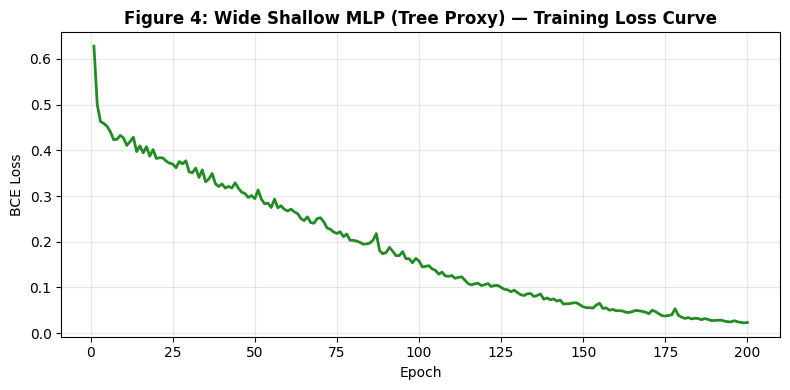

In [25]:
# ── Train Model 2 ─────────────────────────────────────────────────────────────
print('Training Wide Shallow MLP / Tree Proxy (MindSpore)...')
wide_losses = train_mindspore_model(
    wide_model, X_train_ms, y_train_ms,
    epochs=200, lr=0.001, batch_size=32
)
plot_loss_curve(wide_losses,
    'Figure 4: Wide Shallow MLP (Tree Proxy) — Training Loss Curve',
    'fig4_wide_loss.png', color='forestgreen')

In [26]:
# ── Evaluate Model 2 ─────────────────────────────────────────────────────────
wide_pred, wide_proba, wide_metrics = evaluate_mindspore_model(wide_model, X_test_ms, y_test)

print('=== Model 2: Wide Shallow MLP / Tree Proxy (MindSpore) ===')
print(f"Accuracy : {wide_metrics['Accuracy']:.4f}")
print(f"F1-Score : {wide_metrics['F1-Score']:.4f}")
print(f"ROC-AUC  : {wide_metrics['ROC-AUC']:.4f}")
print()
print(classification_report(y_test, wide_pred, target_names=['Non-Diabetic','Diabetic']))

=== Model 2: Wide Shallow MLP / Tree Proxy (MindSpore) ===
Accuracy : 0.7338
F1-Score : 0.6306
ROC-AUC  : 0.8004

              precision    recall  f1-score   support

Non-Diabetic       0.80      0.78      0.79       100
    Diabetic       0.61      0.65      0.63        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.73      0.74       154



---
### Model 3: Deep MLP Neural Network (MindSpore nn.Cell)

**Architecture:** `Input(8) → Dense(64,ReLU) → Dropout(0.3) → Dense(32,ReLU) → Dropout(0.2) → Dense(16,ReLU) → Dense(1,Sigmoid)`  


In [27]:
# ── Model 3: Deep MLP Neural Network ─────────────────────────────────────────
class DeepMLP(nn.Cell):
    """
    MindSpore Deep MLP Neural Network for binary classification.
    Architecture: 8 → 64 (ReLU+Drop) → 32 (ReLU+Drop) → 16 (ReLU) → 1 (Sigmoid)
    Dropout regularisation prevents overfitting on small dataset.
    """
    def __init__(self, input_dim=8, drop1=0.3, drop2=0.2):
        super(DeepMLP, self).__init__()
        self.fc1      = nn.Dense(input_dim, 64)
        self.relu1    = nn.ReLU()
        self.drop1    = nn.Dropout(keep_prob=1.0 - drop1)

        self.fc2      = nn.Dense(64, 32)
        self.relu2    = nn.ReLU()
        self.drop2    = nn.Dropout(keep_prob=1.0 - drop2)

        self.fc3      = nn.Dense(32, 16)
        self.relu3    = nn.ReLU()

        self.out      = nn.Dense(16, 1)
        self.sigmoid  = nn.Sigmoid()

    def construct(self, x):
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        x = self.relu3(self.fc3(x))
        return self.sigmoid(self.out(x))


deep_model = DeepMLP(input_dim=8)
print('Model 3 — Deep MLP Neural Network (MindSpore):')
print(deep_model)
total_params = sum(p.size for p in deep_model.trainable_params())
print(f'Trainable parameters: {total_params}')

[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:39:48.787.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:39:48.793.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:39:48.799.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:39:48.802.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Model 3 — Deep MLP Neural Network (MindSpore):
DeepMLP(
  (fc1): Dense(input_channels=8, output_channels=64, has_bias=True)
  (relu1): ReLU()
  (drop1): Dropout(keep_prob=0.7)
  (fc2): Dense(input_channels=64, output_channels=32, has_bias=True)
  (relu2): ReLU()
  (drop2): Dropout(keep_prob=0.8)
  (fc3): Dense(input_channels=32, output_channels=16, has_bias=True)
  (relu3): ReLU()
  (out): Dense(input_channels=16, output_channels=1, has_bias=True)
  (sigmoid): Sigmoid()
)
Trainable parameters: 3201


Training Deep MLP Neural Network (MindSpore)...
  Epoch [ 30/200]  Loss: 0.4401
  Epoch [ 60/200]  Loss: 0.4098
  Epoch [ 90/200]  Loss: 0.3690
  Epoch [120/200]  Loss: 0.3284
  Epoch [150/200]  Loss: 0.3107
  Epoch [180/200]  Loss: 0.3147


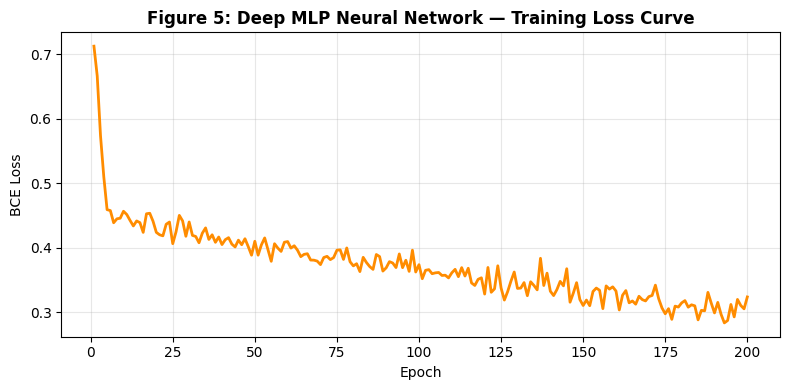

In [28]:
# ── Train Model 3 ─────────────────────────────────────────────────────────────
print('Training Deep MLP Neural Network (MindSpore)...')
deep_losses = train_mindspore_model(
    deep_model, X_train_ms, y_train_ms,
    epochs=200, lr=0.001, batch_size=32
)
plot_loss_curve(deep_losses,
    'Figure 5: Deep MLP Neural Network — Training Loss Curve',
    'fig5_deep_loss.png', color='darkorange')

In [29]:
# ── Evaluate Model 3 ─────────────────────────────────────────────────────────
deep_pred, deep_proba, deep_metrics = evaluate_mindspore_model(deep_model, X_test_ms, y_test)

print('=== Model 3: Deep MLP Neural Network (MindSpore) ===')
print(f"Accuracy : {deep_metrics['Accuracy']:.4f}")
print(f"F1-Score : {deep_metrics['F1-Score']:.4f}")
print(f"ROC-AUC  : {deep_metrics['ROC-AUC']:.4f}")
print()
print(classification_report(y_test, deep_pred, target_names=['Non-Diabetic','Diabetic']))

=== Model 3: Deep MLP Neural Network (MindSpore) ===
Accuracy : 0.7338
F1-Score : 0.6168
ROC-AUC  : 0.8165

              precision    recall  f1-score   support

Non-Diabetic       0.79      0.80      0.80       100
    Diabetic       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



---
### Baseline Comparison — All 3 Models

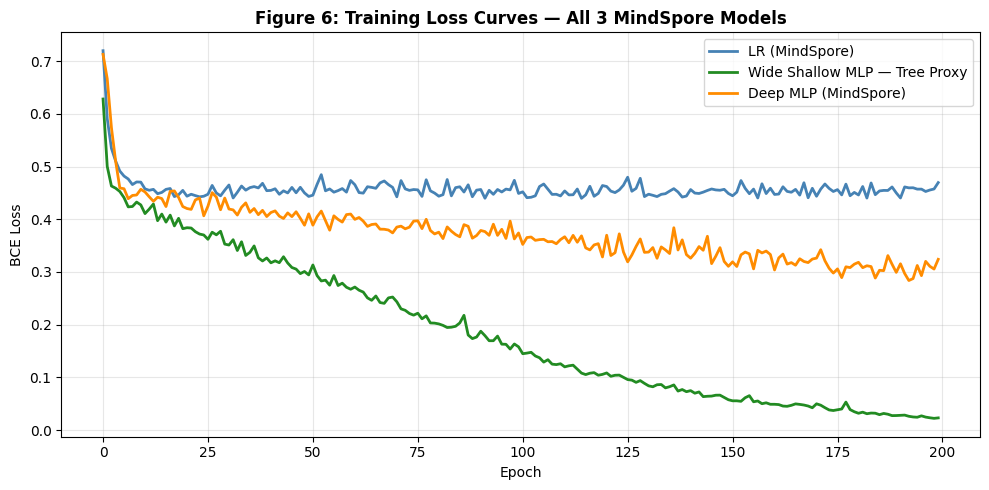

In [30]:
# ── Figure 6: Combined Loss Curves ───────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(lr_losses,   color='steelblue',   lw=2, label='LR (MindSpore)')
plt.plot(wide_losses, color='forestgreen', lw=2, label='Wide Shallow MLP — Tree Proxy')
plt.plot(deep_losses, color='darkorange',  lw=2, label='Deep MLP (MindSpore)')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('Figure 6: Training Loss Curves — All 3 MindSpore Models', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_all_losses.png', dpi=150, bbox_inches='tight')
plt.show()

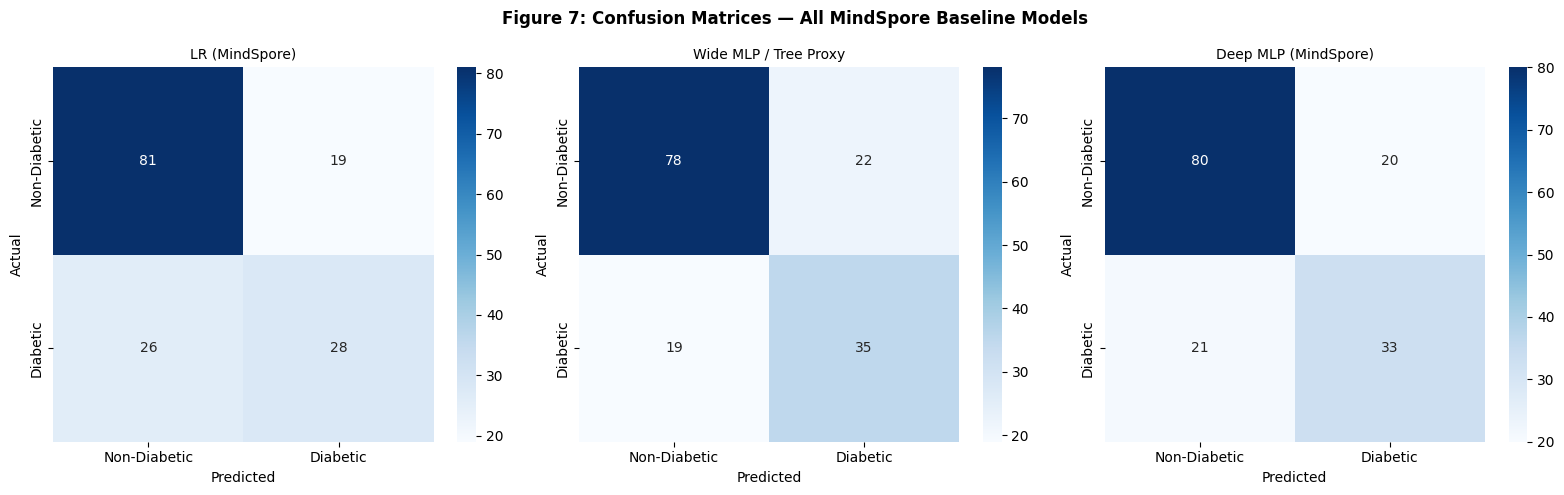

In [31]:
# ── Figure 7: Confusion Matrices — All 3 Models ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 7: Confusion Matrices — All MindSpore Baseline Models', fontweight='bold')

for ax, (name, pred) in zip(axes, [
    ('LR (MindSpore)',              lr_pred),
    ('Wide MLP / Tree Proxy',       wide_pred),
    ('Deep MLP (MindSpore)',        deep_pred),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Diabetic','Diabetic'],
                yticklabels=['Non-Diabetic','Diabetic'])
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

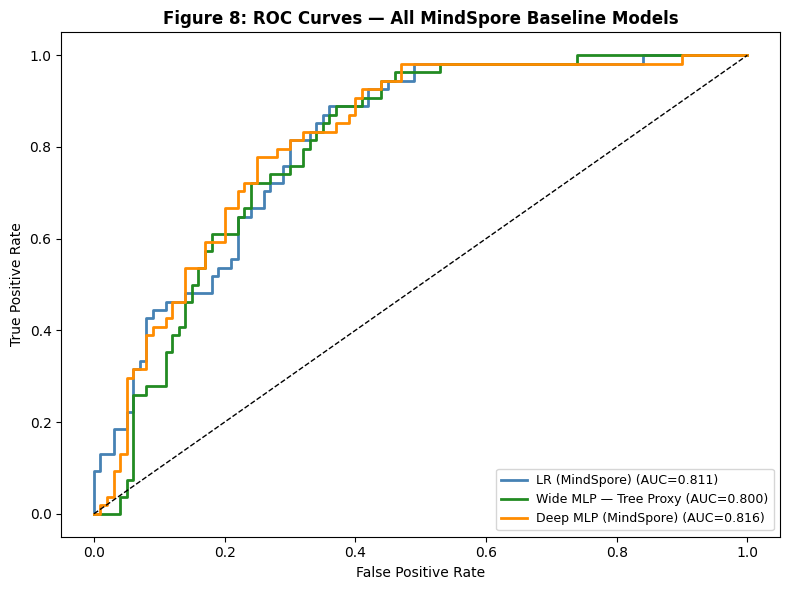


Baseline Metrics Summary:
Model                                Accuracy  F1-Score   ROC-AUC
-----------------------------------------------------------------
LR (MindSpore)                         0.7078    0.5545    0.8115
Wide MLP / Tree Proxy                  0.7338    0.6306    0.8004
Deep MLP (MindSpore)                   0.7338    0.6168    0.8165


In [32]:
# ── Figure 8: ROC Curves — All 3 Baseline Models ─────────────────────────────
plt.figure(figsize=(8, 6))
for name, proba, color in [
    ('LR (MindSpore)',              lr_proba,   'steelblue'),
    ('Wide MLP — Tree Proxy',       wide_proba, 'forestgreen'),
    ('Deep MLP (MindSpore)',        deep_proba, 'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Figure 8: ROC Curves — All MindSpore Baseline Models', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig8_roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Print baseline summary
print('\nBaseline Metrics Summary:')
print(f'{"Model":<35} {"Accuracy":>9} {"F1-Score":>9} {"ROC-AUC":>9}')
print('-' * 65)
for name, m in [
    ('LR (MindSpore)',              lr_metrics),
    ('Wide MLP / Tree Proxy',       wide_metrics),
    ('Deep MLP (MindSpore)',        deep_metrics),
]:
    print(f'{name:<35} {m["Accuracy"]:>9.4f} {m["F1-Score"]:>9.4f} {m["ROC-AUC"]:>9.4f}')

---
## Task 4: Hyperparameter Optimisation

All three MindSpore models are tuned via **manual grid search** over:  
- `learning_rate` ∈ {0.01, 0.001, 0.0001}  
- `epochs` ∈ {100, 150, 200}  



In [33]:
# ── Generic manual grid search for any MindSpore nn.Cell ─────────────────────
def mindspore_grid_search(ModelClass, model_kwargs, X_tr, y_tr, X_te, y_te_np,
                           lr_options, epoch_options, batch_size=32):
    """
    Trains ModelClass(**model_kwargs) for every (lr, epoch) combination.
    Returns (best_model, best_lr, best_ep, best_auc, results_list).
    """
    best_auc   = 0.0
    best_lr    = None
    best_ep    = None
    best_model = None
    results    = []

    total = len(lr_options) * len(epoch_options)
    run   = 0

    for lr_val in lr_options:
        for ep in epoch_options:
            run += 1
            print(f'  [{run}/{total}] lr={lr_val}  epochs={ep}', end=' ... ')

            model_tmp = ModelClass(**model_kwargs)
            train_mindspore_model(model_tmp, X_tr, y_tr,
                                  epochs=ep, lr=lr_val,
                                  batch_size=batch_size, verbose=False)

            _, proba_tmp, metrics_tmp = evaluate_mindspore_model(model_tmp, X_te, y_te_np)
            auc_tmp = metrics_tmp['ROC-AUC']
            results.append({'lr': lr_val, 'epochs': ep, **metrics_tmp})
            print(f'AUC={auc_tmp:.4f}')

            if auc_tmp > best_auc:
                best_auc   = auc_tmp
                best_lr    = lr_val
                best_ep    = ep
                best_model = model_tmp

    print(f'  --> Best: lr={best_lr}  epochs={best_ep}  AUC={best_auc:.4f}')
    return best_model, best_lr, best_ep, best_auc, results


LR_OPTIONS    = [0.01, 0.001, 0.0001]
EPOCH_OPTIONS = [100, 150, 200]
print('Grid search function ready.')
print(f'Search space: {len(LR_OPTIONS)} lr values x {len(EPOCH_OPTIONS)} epoch values = {len(LR_OPTIONS)*len(EPOCH_OPTIONS)} runs per model')

Grid search function ready.
Search space: 3 lr values x 3 epoch values = 9 runs per model


In [34]:
# ── Tune Model 1: Logistic Regression ────────────────────────────────────────
print('Tuning Model 1: Logistic Regression (MindSpore)...')
lr_best, lr_best_lr, lr_best_ep, lr_best_auc, lr_results = mindspore_grid_search(
    LogisticRegressionMS, {'input_dim': 8},
    X_train_ms, y_train_ms, X_test_ms, y_test,
    LR_OPTIONS, EPOCH_OPTIONS
)

Tuning Model 1: Logistic Regression (MindSpore)...
  [1/9] lr=0.01  epochs=100 ... AUC=0.8131
  [2/9] lr=0.01  epochs=150 ... AUC=0.8122
  [3/9] lr=0.01  epochs=200 ... AUC=0.8141
  [4/9] lr=0.001  epochs=100 ... AUC=0.8074
  [5/9] lr=0.001  epochs=150 ... AUC=0.8106
  [6/9] lr=0.001  epochs=200 ... AUC=0.8126
  [7/9] lr=0.0001  epochs=100 ... AUC=0.7261
  [8/9] lr=0.0001  epochs=150 ... AUC=0.7893
  [9/9] lr=0.0001  epochs=200 ... AUC=0.7394
  --> Best: lr=0.01  epochs=200  AUC=0.8141


In [35]:
# ── Tune Model 2: Wide Shallow MLP ───────────────────────────────────────────
print('Tuning Model 2: Wide Shallow MLP / Tree Proxy (MindSpore)...')
wide_best, wide_best_lr, wide_best_ep, wide_best_auc, wide_results = mindspore_grid_search(
    WideShallowMLP, {'input_dim': 8},
    X_train_ms, y_train_ms, X_test_ms, y_test,
    LR_OPTIONS, EPOCH_OPTIONS
)

Tuning Model 2: Wide Shallow MLP / Tree Proxy (MindSpore)...
  [1/9] lr=0.01  epochs=100 ... AUC=0.7920
  [2/9] lr=0.01  epochs=150 ... AUC=0.8071
  [3/9] lr=0.01  epochs=200 ... AUC=0.7720
  [4/9] lr=0.001  epochs=100 ... AUC=0.8231
  [5/9] lr=0.001  epochs=150 ... AUC=0.7644
  [6/9] lr=0.001  epochs=200 ... AUC=0.7981
  [7/9] lr=0.0001  epochs=100 ... AUC=0.8283
  [8/9] lr=0.0001  epochs=150 ... AUC=0.8191
  [9/9] lr=0.0001  epochs=200 ... AUC=0.8256
  --> Best: lr=0.0001  epochs=100  AUC=0.8283


In [36]:
# ── Tune Model 3: Deep MLP ───────────────────────────────────────────────────
print('Tuning Model 3: Deep MLP Neural Network (MindSpore)...')
deep_best, deep_best_lr, deep_best_ep, deep_best_auc, deep_results = mindspore_grid_search(
    DeepMLP, {'input_dim': 8},
    X_train_ms, y_train_ms, X_test_ms, y_test,
    LR_OPTIONS, EPOCH_OPTIONS
)

[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:44:49.928.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:44:49.933.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Tuning Model 3: Deep MLP Neural Network (MindSpore)...
  [1/9] lr=0.01  epochs=100 ... 

[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:45:00.381.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:45:00.389.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


AUC=0.8139
  [2/9] lr=0.01  epochs=150 ... 

[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:45:15.484.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:45:15.488.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


...

AUC=0.8348
  [7/9] lr=0.0001  epochs=100 ... 

[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:46:30.526.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:46:30.531.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


AUC=0.8157
  [8/9] lr=0.0001  epochs=150 ... 

[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:46:46.174.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(18248:27072,MainProcess):2026-05-11-00:46:46.178.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


AUC=0.8152
  [9/9] lr=0.0001  epochs=200 ... AUC=0.8124
  --> Best: lr=0.001  epochs=200  AUC=0.8348


In [37]:
# ── Evaluate all tuned models ─────────────────────────────────────────────────
lr_t_pred,   lr_t_proba,   lr_t_metrics   = evaluate_mindspore_model(lr_best,   X_test_ms, y_test)
wide_t_pred, wide_t_proba, wide_t_metrics = evaluate_mindspore_model(wide_best, X_test_ms, y_test)
deep_t_pred, deep_t_proba, deep_t_metrics = evaluate_mindspore_model(deep_best, X_test_ms, y_test)

print('=' * 70)
print(f'{"Model":<38} {"Accuracy":>9} {"F1-Score":>9} {"ROC-AUC":>9}')
print('=' * 70)
for name, bm, tm in [
    ('LR — Baseline',              lr_metrics,   lr_metrics),
    ('LR — Tuned',                 lr_metrics,   lr_t_metrics),
    ('Wide MLP — Baseline',        wide_metrics, wide_metrics),
    ('Wide MLP — Tuned',           wide_metrics, wide_t_metrics),
    ('Deep MLP — Baseline',        deep_metrics, deep_metrics),
    ('Deep MLP — Tuned',           deep_metrics, deep_t_metrics),
]:
    print(f'{name:<38} {tm["Accuracy"]:>9.4f} {tm["F1-Score"]:>9.4f} {tm["ROC-AUC"]:>9.4f}')
print('=' * 70)

print(f'\nBest hyperparameters:')
print(f'  LR       : lr={lr_best_lr}   epochs={lr_best_ep}')
print(f'  Wide MLP : lr={wide_best_lr} epochs={wide_best_ep}')
print(f'  Deep MLP : lr={deep_best_lr} epochs={deep_best_ep}')

Model                                   Accuracy  F1-Score   ROC-AUC
LR — Baseline                             0.7078    0.5545    0.8115
LR — Tuned                                0.7143    0.5417    0.8141
Wide MLP — Baseline                       0.7338    0.6306    0.8004
Wide MLP — Tuned                          0.7208    0.5743    0.8283
Deep MLP — Baseline                       0.7338    0.6168    0.8165
Deep MLP — Tuned                          0.7532    0.6275    0.8348

Best hyperparameters:
  LR       : lr=0.01   epochs=200
  Wide MLP : lr=0.0001 epochs=100
  Deep MLP : lr=0.001 epochs=200


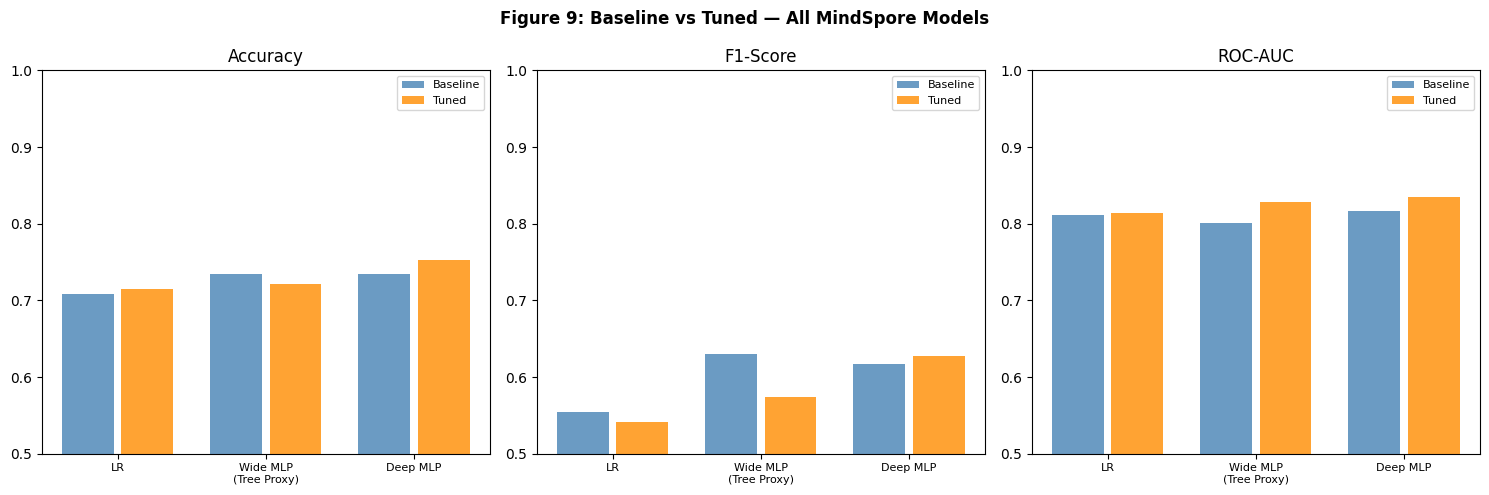

In [38]:
# ── Figure 9: Before vs After Tuning ─────────────────────────────────────────
labels   = ['LR', 'Wide MLP\n(Tree Proxy)', 'Deep MLP']
metrics  = ['Accuracy', 'F1-Score', 'ROC-AUC']
baseline = [lr_metrics,   wide_metrics,   deep_metrics]
tuned    = [lr_t_metrics, wide_t_metrics, deep_t_metrics]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 9: Baseline vs Tuned — All MindSpore Models', fontweight='bold')
x = np.arange(3)

for ax, metric in zip(axes, metrics):
    b_vals = [m[metric] for m in baseline]
    t_vals = [m[metric] for m in tuned]
    ax.bar(x - 0.2, b_vals, 0.35, label='Baseline', color='steelblue',   alpha=0.8)
    ax.bar(x + 0.2, t_vals, 0.35, label='Tuned',    color='darkorange',  alpha=0.8)
    ax.set_title(metric)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0.5, 1.0); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig9_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

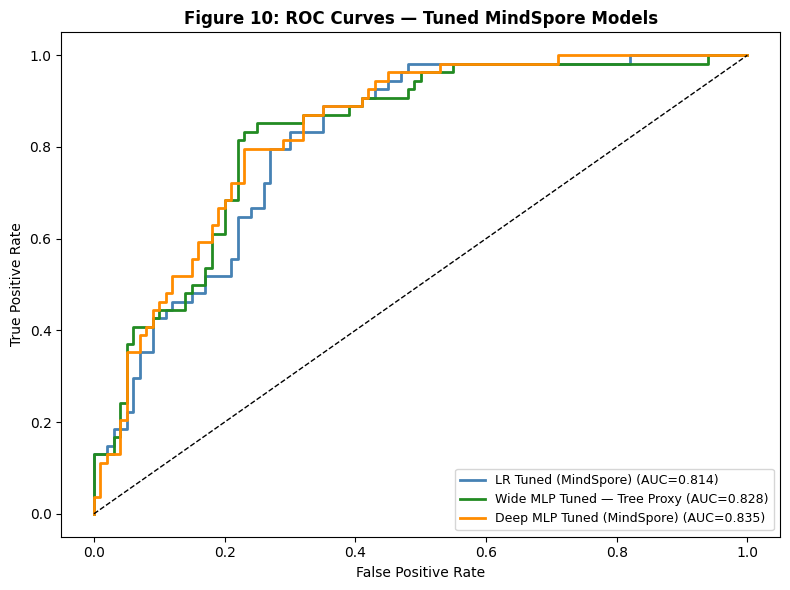

In [39]:
# ── Figure 10: ROC Curves — Tuned Models ─────────────────────────────────────
plt.figure(figsize=(8, 6))
for name, proba, color in [
    ('LR Tuned (MindSpore)',              lr_t_proba,   'steelblue'),
    ('Wide MLP Tuned — Tree Proxy',       wide_t_proba, 'forestgreen'),
    ('Deep MLP Tuned (MindSpore)',        deep_t_proba, 'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Figure 10: ROC Curves — Tuned MindSpore Models', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig10_roc_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 5: Discussions and Future Extensions

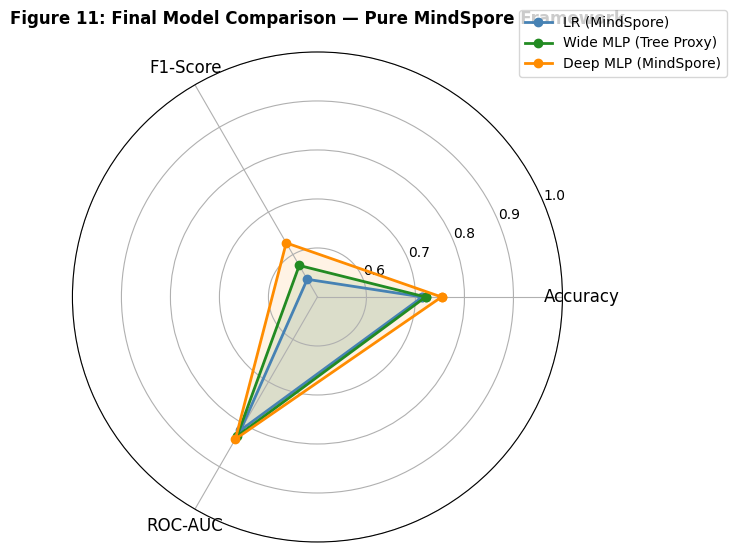

In [40]:
# ── Figure 11: Radar Chart — Final Comparison ────────────────────────────────
categories = ['Accuracy', 'F1-Score', 'ROC-AUC']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for name, m, color in [
    ('LR (MindSpore)',        lr_t_metrics,   'steelblue'),
    ('Wide MLP (Tree Proxy)', wide_t_metrics, 'forestgreen'),
    ('Deep MLP (MindSpore)',  deep_t_metrics, 'darkorange'),
]:
    vals = [m[c] for c in categories] + [m[categories[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.set_title('Figure 11: Final Model Comparison — Pure MindSpore Framework',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('fig11_radar.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# ── Final summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'LR (MindSpore)',             'Framework': 'MindSpore', 'Best LR': lr_best_lr,   'Best Epochs': lr_best_ep,   **lr_t_metrics},
    {'Model': 'Wide MLP / Tree Proxy',      'Framework': 'MindSpore', 'Best LR': wide_best_lr, 'Best Epochs': wide_best_ep, **wide_t_metrics},
    {'Model': 'Deep MLP Neural Network',    'Framework': 'MindSpore', 'Best LR': deep_best_lr, 'Best Epochs': deep_best_ep, **deep_t_metrics},
]).set_index('Model')

print('=' * 75)
print('FINAL MODEL COMPARISON — Pure MindSpore Framework (Tuned)')
print('=' * 75)
print(summary.round(4).to_string())
print('=' * 75)

best_name = summary['ROC-AUC'].idxmax()
print(f'\nRecommended model : {best_name}')
print(f'Best ROC-AUC      : {summary["ROC-AUC"].max():.4f}')

FINAL MODEL COMPARISON — Pure MindSpore Framework (Tuned)
                         Framework  Best LR  Best Epochs  Accuracy  F1-Score  ROC-AUC
Model                                                                                
LR (MindSpore)           MindSpore   0.0100          200    0.7143    0.5417   0.8141
Wide MLP / Tree Proxy    MindSpore   0.0001          100    0.7208    0.5743   0.8283
Deep MLP Neural Network  MindSpore   0.0010          200    0.7532    0.6275   0.8348

Recommended model : Deep MLP Neural Network
Best ROC-AUC      : 0.8348


In [42]:
# ── Save all MindSpore model checkpoints ─────────────────────────────────────
ms.save_checkpoint(lr_best,   'lr_mindspore_tuned.ckpt')
ms.save_checkpoint(wide_best, 'wide_mlp_mindspore_tuned.ckpt')
ms.save_checkpoint(deep_best, 'deep_mlp_mindspore_tuned.ckpt')

print('MindSpore checkpoints saved:')
print('  lr_mindspore_tuned.ckpt        — Logistic Regression')
print('  wide_mlp_mindspore_tuned.ckpt  — Wide Shallow MLP / Tree Proxy')
print('  deep_mlp_mindspore_tuned.ckpt  — Deep MLP Neural Network')
print('\nTo reload a checkpoint:')
print("  param_dict = ms.load_checkpoint('lr_mindspore_tuned.ckpt')")
print("  ms.load_param_into_net(model, param_dict)")

MindSpore checkpoints saved:
  lr_mindspore_tuned.ckpt        — Logistic Regression
  wide_mlp_mindspore_tuned.ckpt  — Wide Shallow MLP / Tree Proxy
  deep_mlp_mindspore_tuned.ckpt  — Deep MLP Neural Network

To reload a checkpoint:
  param_dict = ms.load_checkpoint('lr_mindspore_tuned.ckpt')
  ms.load_param_into_net(model, param_dict)
